In [1]:
import os
import re
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, classification_report
)

BASE        = '/kaggle/input/datasets/irfan020/race-preprocessed/processed'

MODEL_PATH  = '/kaggle/working/models'
IMAGES_PATH = '/kaggle/working/images'
os.makedirs(MODEL_PATH,  exist_ok=True)
os.makedirs(IMAGES_PATH, exist_ok=True)

train_options = pd.read_csv(f'{BASE}/train_options.csv')
dev_options   = pd.read_csv(f'{BASE}/dev_options.csv')
test_options  = pd.read_csv(f'{BASE}/test_options.csv')

print(f'Train options: {train_options.shape}')
print(f'Dev options:   {dev_options.shape}')
print(f'Test options:  {test_options.shape}')
print(f'Class balance: {train_options["label"].mean():.2f}')

Train options: (281168, 6)
Dev options:   (35148, 6)
Test options:  (35148, 6)
Class balance: 0.25


In [2]:
print('Vectorizing')
vectorizer = TfidfVectorizer(
    max_features = 10000,
    stop_words   = 'english',
    sublinear_tf = True,
    ngram_range  = (1, 2),
    min_df       = 2,
    max_df       = 0.95
)

X_train = vectorizer.fit_transform(train_options['combined_text'])
X_dev   = vectorizer.transform(dev_options['combined_text'])
X_test  = vectorizer.transform(test_options['combined_text'])

y_train = train_options['label']
y_dev   = dev_options['label']
y_test  = test_options['label']

print(f'Train matrix: {X_train.shape}')
print(f'Dev matrix:   {X_dev.shape}')

joblib.dump(vectorizer, f'{MODEL_PATH}/vectorizer.pkl')

Vectorizing
Train matrix: (281168, 10000)
Dev matrix:   (35148, 10000)


['/kaggle/working/models/vectorizer.pkl']

In [3]:
print('Training Logistic Regression')
lr_model = LogisticRegression(
    class_weight = 'balanced',
    max_iter     = 1000,
    C            = 1.0,
    random_state = 42
)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_dev)

print(f'Accuracy:  {accuracy_score(y_dev, lr_preds):.4f}')
print(f'F1 Macro:  {f1_score(y_dev, lr_preds, average="macro"):.4f}')
print(f'Precision: {precision_score(y_dev, lr_preds, average="macro"):.4f}')
print(f'Recall:    {recall_score(y_dev, lr_preds, average="macro"):.4f}')
print(classification_report(y_dev, lr_preds))

joblib.dump(lr_model, f'{MODEL_PATH}/logistic_regression.pkl')

Training Logistic Regression
Accuracy:  0.7500
F1 Macro:  0.4286
Precision: 0.3750
Recall:    0.5000
              precision    recall  f1-score   support

           0       0.75      1.00      0.86     26361
           1       0.00      0.00      0.00      8787

    accuracy                           0.75     35148
   macro avg       0.38      0.50      0.43     35148
weighted avg       0.56      0.75      0.64     35148



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

['/kaggle/working/models/logistic_regression.pkl']

In [4]:
print('Training SVM')
svm_model = LinearSVC(
    class_weight = 'balanced',
    max_iter     = 2000,
    C            = 1.0,
    random_state = 42
)
svm_model.fit(X_train, y_train)
svm_preds = svm_model.predict(X_dev)

print(f'Accuracy:  {accuracy_score(y_dev, svm_preds):.4f}')
print(f'F1 Macro:  {f1_score(y_dev, svm_preds, average="macro"):.4f}')
print(f'Precision: {precision_score(y_dev, svm_preds, average="macro"):.4f}')
print(f'Recall:    {recall_score(y_dev, svm_preds, average="macro"):.4f}')
print(classification_report(y_dev, svm_preds))

joblib.dump(svm_model, f'{MODEL_PATH}/svm_classifier.pkl')

Training SVM
Accuracy:  0.5179
F1 Macro:  0.4813
Precision: 0.5100
Recall:    0.5134
              precision    recall  f1-score   support

           0       0.76      0.52      0.62     26361
           1       0.26      0.50      0.34      8787

    accuracy                           0.52     35148
   macro avg       0.51      0.51      0.48     35148
weighted avg       0.63      0.52      0.55     35148



['/kaggle/working/models/svm_classifier.pkl']

In [5]:
print('Training Naive Bayes')
scaler         = MaxAbsScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_dev_scaled   = scaler.transform(X_dev)
X_test_scaled  = scaler.transform(X_test)

nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_scaled, y_train)
nb_preds = nb_model.predict(X_dev_scaled)

print(f'Accuracy:  {accuracy_score(y_dev, nb_preds):.4f}')
print(f'F1 Macro:  {f1_score(y_dev, nb_preds, average="macro"):.4f}')
print(f'Precision: {precision_score(y_dev, nb_preds, average="macro"):.4f}')
print(f'Recall:    {recall_score(y_dev, nb_preds, average="macro"):.4f}')
print(classification_report(y_dev, nb_preds))

joblib.dump(nb_model, f'{MODEL_PATH}/naive_bayes.pkl')
joblib.dump(scaler,   f'{MODEL_PATH}/scaler.pkl')

Training Naive Bayes
Accuracy:  0.7500
F1 Macro:  0.4286
Precision: 0.3750
Recall:    0.5000
              precision    recall  f1-score   support

           0       0.75      1.00      0.86     26361
           1       0.00      0.00      0.00      8787

    accuracy                           0.75     35148
   macro avg       0.38      0.50      0.43     35148
weighted avg       0.56      0.75      0.64     35148



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

['/kaggle/working/models/scaler.pkl']

Model Comparison:
              Model  Accuracy  F1 Macro  Precision  Recall
Logistic Regression    0.7500    0.4286      0.375  0.5000
                SVM    0.5179    0.4813      0.510  0.5134
        Naive Bayes    0.7500    0.4286      0.375  0.5000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


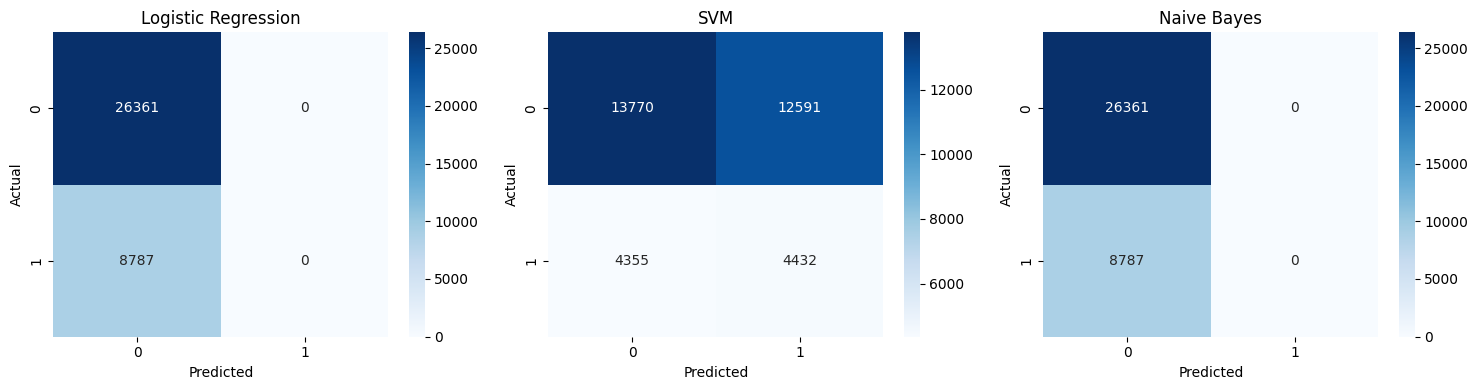

In [6]:
models = {
    'Logistic Regression': lr_preds,
    'SVM':                 svm_preds,
    'Naive Bayes':         nb_preds
}

results = []
for name, preds in models.items():
    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_dev, preds), 4),
        'F1 Macro':  round(f1_score(y_dev, preds, average='macro'), 4),
        'Precision': round(precision_score(y_dev, preds, average='macro'), 4),
        'Recall':    round(recall_score(y_dev, preds, average='macro'), 4)
    })

results_df = pd.DataFrame(results)
print('Model Comparison:')
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, preds) in zip(axes, models.items()):
    cm = confusion_matrix(y_dev, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(f'{IMAGES_PATH}/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
print('TEST SET EVALUATION')
lr_test_preds  = lr_model.predict(X_test)
svm_test_preds = svm_model.predict(X_test)
nb_test_preds  = nb_model.predict(X_test_scaled)

for name, preds in [('LR', lr_test_preds), ('SVM', svm_test_preds), ('NB', nb_test_preds)]:
    print(f'\n{name}:')
    print(f'Accuracy:  {accuracy_score(y_test, preds):.4f}')
    print(f'F1 Macro:  {f1_score(y_test, preds, average="macro"):.4f}')

print('\nAll models saved:')
print(os.listdir(MODEL_PATH))

TEST SET EVALUATION

LR:
Accuracy:  0.7500
F1 Macro:  0.4286

SVM:
Accuracy:  0.5170
F1 Macro:  0.4802

NB:
Accuracy:  0.7500
F1 Macro:  0.4286

All models saved:
['naive_bayes.pkl', 'logistic_regression.pkl', 'scaler.pkl', 'svm_classifier.pkl', 'vectorizer.pkl']


UNSUPERVISED & SEMI-SUPERVISED LEARNING

Reducing dimensions with TruncatedSVD (LSA)
Reduced shape: (281168, 100)

K-Means Clustering
Silhouette Score: 0.0523
Cluster Purity:   0.7503
Accuracy (mapped): 0.7500
F1 Macro (mapped): 0.4286


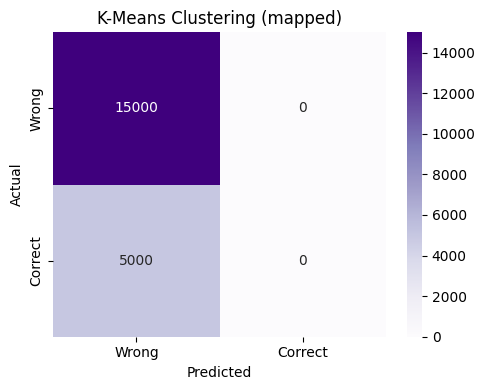

K-Means confusion matrix saved.

Label Propagation (Semi-Supervised)
Labeled samples:   608
Unlabeled samples: 2392


/usr/local/lib/python3.12/dist-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer
/usr/local/lib/python3.12/dist-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer


Accuracy on unlabeled: 0.6430
F1 Macro on unlabeled: 0.4633
Dev Accuracy: 0.6863
Dev F1 Macro: 0.4824


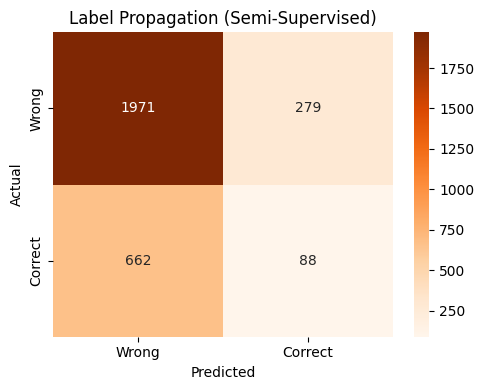

Label Propagation confusion matrix saved.

--- Full Model Comparison ---
                              Model            Type  Accuracy  F1 Macro
   Logistic Regression (Supervised)      Supervised    0.7500    0.4286
                   SVM (Supervised)      Supervised    0.5179    0.4813
           Naive Bayes (Supervised)      Supervised    0.7500    0.4286
             K-Means (Unsupervised)    Unsupervised    0.7500    0.4286
Label Propagation (Semi-Supervised) Semi-Supervised    0.6863    0.4824


/tmp/ipykernel_16/1336190743.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comparison['Model'], rotation=20, ha='right', fontsize=8)
/tmp/ipykernel_16/1336190743.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comparison['Model'], rotation=20, ha='right', fontsize=8)


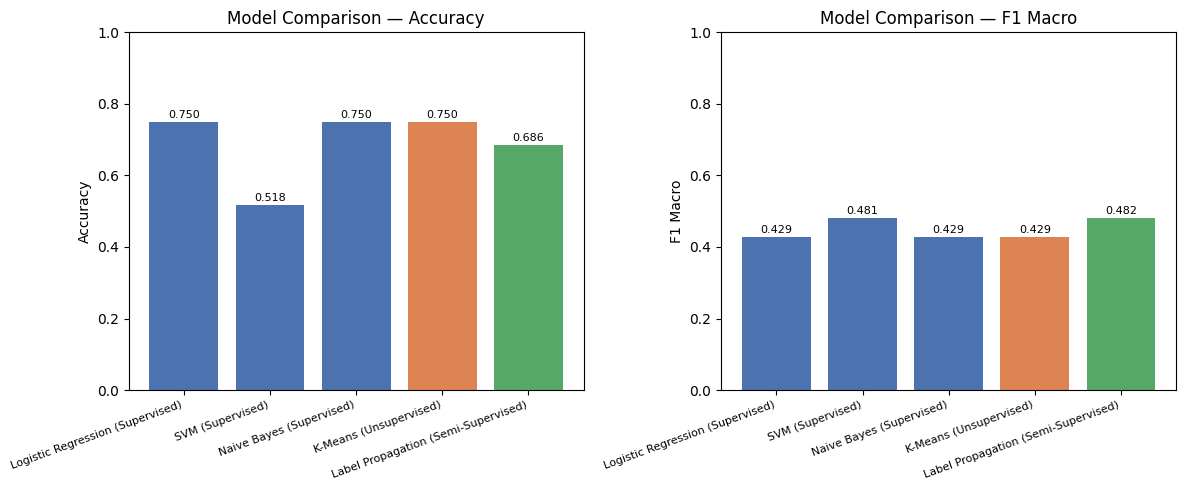


All unsupervised/semi-supervised models saved.
['kmeans_model.pkl', 'naive_bayes.pkl', 'svd_reducer.pkl', 'logistic_regression.pkl', 'label_propagation.pkl', 'scaler.pkl', 'svm_classifier.pkl', 'vectorizer.pkl']


In [8]:
from sklearn.cluster import KMeans
from sklearn.semi_supervised import LabelPropagation
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD

print('=' * 60)
print('UNSUPERVISED & SEMI-SUPERVISED LEARNING')
print('=' * 60)

print('\nReducing dimensions with TruncatedSVD (LSA)')
svd = TruncatedSVD(n_components=100, random_state=42)
X_train_dense = svd.fit_transform(X_train)
X_dev_dense   = svd.transform(X_dev)
X_test_dense  = svd.transform(X_test)
print(f'Reduced shape: {X_train_dense.shape}')
joblib.dump(svd, f'{MODEL_PATH}/svd_reducer.pkl')


print('\nK-Means Clustering')

# Use a subset for speed (KMeans on 281k rows is slow)
N = 20000
X_km = X_train_dense[:N]
y_km = y_train.values[:N]

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_km)

# Silhouette score (clustering quality, no labels needed)
sil = silhouette_score(X_km, km_labels, sample_size=5000, random_state=42)
print(f'Silhouette Score: {sil:.4f}')

# Cluster purity (how well clusters align with true labels)
def cluster_purity(y_true, y_pred):
    from scipy.stats import mode
    purities = []
    for cluster in np.unique(y_pred):
        mask = y_pred == cluster
        if mask.sum() == 0:
            continue
        majority = mode(y_true[mask], keepdims=True).count[0]
        purities.append(majority / mask.sum())
    return np.mean(purities)

purity = cluster_purity(y_km, km_labels)
print(f'Cluster Purity:   {purity:.4f}')

# Map cluster → label (majority vote per cluster)
km_mapped = np.zeros_like(km_labels)
for cluster in np.unique(km_labels):
    mask = km_labels == cluster
    from scipy.stats import mode
    majority_label = mode(y_km[mask], keepdims=True).mode[0]
    km_mapped[mask] = majority_label

km_f1 = f1_score(y_km, km_mapped, average='macro')
km_acc = accuracy_score(y_km, km_mapped)
print(f'Accuracy (mapped): {km_acc:.4f}')
print(f'F1 Macro (mapped): {km_f1:.4f}')

joblib.dump(kmeans, f'{MODEL_PATH}/kmeans_model.pkl')

# Confusion matrix for KMeans
fig, ax = plt.subplots(figsize=(5, 4))
cm_km = confusion_matrix(y_km, km_mapped)
sns.heatmap(cm_km, annot=True, fmt='d', cmap='Purples', ax=ax,
            xticklabels=['Wrong','Correct'], yticklabels=['Wrong','Correct'])
ax.set_title('K-Means Clustering (mapped)')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(f'{IMAGES_PATH}/kmeans_confusion.png', dpi=150)
plt.show()
print('K-Means confusion matrix saved.')

print('\nLabel Propagation (Semi-Supervised)')

N_lp    = 3000
X_lp    = X_train_dense[:N_lp]
y_full  = y_train.values[:N_lp]

np.random.seed(42)
mask        = np.random.rand(N_lp) < 0.80
y_lp        = y_full.copy()
y_lp[mask]  = -1   # -1 = unlabeled in sklearn

print(f'Labeled samples:   {(y_lp != -1).sum()}')
print(f'Unlabeled samples: {(y_lp == -1).sum()}')

lp_model = LabelPropagation(kernel='knn', n_neighbors=7, max_iter=1000)
lp_model.fit(X_lp, y_lp)

unlabeled_idx  = np.where(mask)[0]
lp_preds_train = lp_model.predict(X_lp[unlabeled_idx])
lp_true        = y_full[unlabeled_idx]

lp_acc = accuracy_score(lp_true, lp_preds_train)
lp_f1  = f1_score(lp_true, lp_preds_train, average='macro')
print(f'Accuracy on unlabeled: {lp_acc:.4f}')
print(f'F1 Macro on unlabeled: {lp_f1:.4f}')

lp_dev_preds = lp_model.predict(X_dev_dense[:N_lp])
lp_dev_acc   = accuracy_score(y_dev.values[:N_lp], lp_dev_preds)
lp_dev_f1    = f1_score(y_dev.values[:N_lp], lp_dev_preds, average='macro')
print(f'Dev Accuracy: {lp_dev_acc:.4f}')
print(f'Dev F1 Macro: {lp_dev_f1:.4f}')

joblib.dump(lp_model, f'{MODEL_PATH}/label_propagation.pkl')

fig, ax = plt.subplots(figsize=(5, 4))
cm_lp = confusion_matrix(y_dev.values[:N_lp], lp_dev_preds)
sns.heatmap(cm_lp, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=['Wrong','Correct'], yticklabels=['Wrong','Correct'])
ax.set_title('Label Propagation (Semi-Supervised)')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(f'{IMAGES_PATH}/label_prop_confusion.png', dpi=150)
plt.show()
print('Label Propagation confusion matrix saved.')

print('\n--- Full Model Comparison ---')
comparison = pd.DataFrame([
    {'Model': 'Logistic Regression (Supervised)', 'Type': 'Supervised',
     'Accuracy': accuracy_score(y_dev, lr_preds),
     'F1 Macro': f1_score(y_dev, lr_preds, average='macro')},
    {'Model': 'SVM (Supervised)', 'Type': 'Supervised',
     'Accuracy': accuracy_score(y_dev, svm_preds),
     'F1 Macro': f1_score(y_dev, svm_preds, average='macro')},
    {'Model': 'Naive Bayes (Supervised)', 'Type': 'Supervised',
     'Accuracy': accuracy_score(y_dev, nb_preds),
     'F1 Macro': f1_score(y_dev, nb_preds, average='macro')},
    {'Model': 'K-Means (Unsupervised)', 'Type': 'Unsupervised',
     'Accuracy': km_acc,
     'F1 Macro': km_f1},
    {'Model': 'Label Propagation (Semi-Supervised)', 'Type': 'Semi-Supervised',
     'Accuracy': lp_dev_acc,
     'F1 Macro': lp_dev_f1},
])
comparison['Accuracy'] = comparison['Accuracy'].round(4)
comparison['F1 Macro'] = comparison['F1 Macro'].round(4)
print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#4C72B0','#4C72B0','#4C72B0','#DD8452','#55A868']
for ax, metric in zip(axes, ['Accuracy', 'F1 Macro']):
    bars = ax.bar(comparison['Model'], comparison[metric], color=colors)
    ax.set_title(f'Model Comparison — {metric}')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.set_xticklabels(comparison['Model'], rotation=20, ha='right', fontsize=8)
    for bar, val in zip(bars, comparison[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(f'{IMAGES_PATH}/model_comparison.png', dpi=150)
plt.show()
print('\nAll unsupervised/semi-supervised models saved.')
print(os.listdir(MODEL_PATH))